# 04 — Theory composites and validity

The first three notebooks worked bottom-up: topics, then taxonomy leaves, then inside the
leaves. This one works top-down. Romance scholarship makes claims about constructs —
*love over sex*, *happily-ever-after*, *protective versus possessive love* — and each of
those has to be turned into a number before it can be tested.

A composite is a weighted combination of taxonomy leaves, defined in
`configs/stage09/theory_aligned_index_schema.yaml` **before** any outcome was looked at. That
ordering is the whole point: the axes are not tuned to predict ratings, so notebook 05 can
test them rather than merely fit them.

**What this notebook does, and why each step is necessary**

1. Shows every axis definition, and what corpus evidence each rests on.
2. Checks whether each axis holds together — a sum of things that do not covary is not a
   measurement of anything.
3. Checks whether the axes are distinct from each other, since several share leaves by
   construction.
4. Reports which hypotheses are testable, which are underpowered, and which are not
   measurable at all in this model. Notebook 03 showed that leaf-level pooling can cancel
   signal, so this step is not a formality.

Nothing here touches the rating outcome. That separation is deliberate.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = cwd
for _ in range(6):
    if (project_root / "configs").is_dir() and (project_root / "src").is_dir():
        break
    project_root = project_root.parent
else:
    raise RuntimeError("Could not find project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.stage10_correlation_analysis.analysis import axes as axes_mod
from src.stage10_correlation_analysis.analysis import compositional as comp
from src.stage10_correlation_analysis.analysis import models as mdl
from src.stage10_correlation_analysis.analysis import notebook_helpers as nbh
from src.stage10_correlation_analysis.analysis import reliability as rel

ctx = nbh.setup("04_composites_validity")
cfg = ctx.cfg
SEED = int(cfg.section("inference", "bootstrap", "seed"))

frame = nbh.load_analysis_frame(cfg).reset_index()
topic_lookup = nbh.load_topic_lookup(cfg)
axis_coverage = nbh.load_book_features(cfg, "axis_coverage")
axis_summary = nbh.load_book_features(cfg, "axis_coverage_summary")
axis_definitions = nbh.load_book_features(cfg, "axis_definitions")

AXIS_COLS = [c for c in frame.columns if c.startswith("AX_") and not c.endswith(("_z", "_clr"))]
LEAF_COLS = nbh.columns_with_prefix(frame, "leaf_")
LOG_RATIO_COLS = nbh.columns_with_prefix(frame, "LR_")

print(f"\n{len(AXIS_COLS)} axes built | {len(LOG_RATIO_COLS)} explicit log-ratio forms")
print(f"Schema: {cfg.section('axes', 'schema')}")

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage10/final_analysis.yaml
Run          : v4_l12_granular_final_call49
Model        : BERTopic call_49 — MiniLM-L12, 374 topics (348 mapped + outliers)
Outputs      : results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity



28 axes built | 2 explicit log-ratio forms
Schema: configs/stage09/theory_aligned_index_schema.yaml


## 1. What the axes are

Every axis, spelled out. A signed weight means the axis is a *contrast*: `AX_love_over_sex`
adds the emotional-intimacy leaves and subtracts explicit sex, so a positive value means a
book leans emotional relative to explicit — not that it contains a lot of either.

`role` separates the six confirmatory axes, which carry the pre-registered hypotheses, from
the exploratory ones that are described but not used to claim anything.

In [2]:
display(axis_definitions.sort_values(["role", "axis"]))
ctx.save_table(axis_definitions, "axis_definitions")

confirmatory = axis_definitions[axis_definitions["role"] == "confirmatory"]
print(f"\nConfirmatory axes: {len(confirmatory)}")
for row in confirmatory.itertuples():
    print(f"  {row.hypothesis:<6} {row.axis:<38} {row.definition}")

,axis,method,definition,hypothesis,role
0,AX_dark_vs_tender,difference,+1*3.2 +1*4.4 +1*7.2 +1*7.3 -1*3.1 -1*2.2 -1*4.6,H5,confirmatory
1,AX_explicitness,weighted_sum,+1*2.3,H1,confirmatory
2,AX_hea_index,weighted_sum,+1*4.5 +0.8*5.3a +0.5*8.3a,H2,confirmatory
3,AX_love_over_sex,difference,+1*4.5 +1*3.1 -1*2.3,H1,confirmatory
4,AX_luxury_composite,weighted_sum_from_composite,+1*6.6 +1*6.7 +0.7*6.1a +0.3*5.3a +0.3*8.2,H3,confirmatory
5,AX_luxury_x_love,product,AX_luxury_composite x AX_payoff_safety,H3,confirmatory
6,AX_material_display_x_payoff,product,AX_material_social_display x AX_payoff_safety,H3,confirmatory
7,AX_material_social_display,weighted_sum,+1*1.6 +1*8.2 +0.5*5.3a +0.5*8.3a,H3,confirmatory
8,AX_miscommunication,weighted_sum,+1*4.3,H6,confirmatory
9,AX_payoff_safety,weighted_sum,+1*4.5 +1*3.1,"H2,H3",confirmatory


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/tables/axis_definitions.csv  (26 rows)

Confirmatory axes: 14
  H5     AX_dark_vs_tender                      +1*3.2 +1*4.4 +1*7.2 +1*7.3 -1*3.1 -1*2.2 -1*4.6
  H1     AX_explicitness                        +1*2.3
  H2     AX_hea_index                           +1*4.5 +0.8*5.3a +0.5*8.3a
  H1     AX_love_over_sex                       +1*4.5 +1*3.1 -1*2.3
  H3     AX_luxury_composite                    +1*6.6 +1*6.7 +0.7*6.1a +0.3*5.3a +0.3*8.2
  H3     AX_luxury_x_love                       AX_luxury_composite x AX_payoff_safety
  H3     AX_material_display_x_payoff           AX_material_social_display x AX_payoff_safety
  H3     AX_material_social_display             +1*1.6 +1*8.2 +0.5*5.3a +0.5*8.3a
  H6     AX_miscommunication                    +1*4.3
  H2,H3  AX_payoff_safety                       +1*4.5 +1*3.1
  H4     AX_possessiveness                      +

## 2. What each axis actually rests on

A definition is a promise; coverage is what was delivered. `n_topics` is how many of the
model's 348 mapped topics fall into each component leaf, and the verdict is mechanical:
three or more topics is *viable*, one or two is *weak*, zero is *empty*.

This table is why the rebuild exists. The previous pipeline emitted four axes as exactly
`0.0` for every book because their components had no topics, and a column of zeros is
indistinguishable from a real variable in a regression table.

In [3]:
display(axis_summary[["axis", "hypothesis", "hypothesis_role", "axis_verdict", "n_components",
                      "n_viable", "n_weak", "n_empty", "total_topics", "empty_leaves"]])
ctx.save_table(axis_summary, "axis_coverage_summary")

verdict_counts = axis_summary["axis_verdict"].value_counts()
print("\nAxis verdicts (an axis is only as strong as its weakest signed leg):")
display(verdict_counts.to_frame("n_axes"))

weak_axes = axis_summary[axis_summary["axis_verdict"] == "weak"]
print(f"\n{len(weak_axes)} axes are weak. Which leg is thin, per axis:")
for row in weak_axes.itertuples():
    thin = axis_coverage[
        (axis_coverage["axis"] == row.axis) & (axis_coverage["verdict"].isin(["weak", "empty"]))
    ]
    detail = ", ".join(f"{r.leaf_id} ({r.n_topics} topics, {r.verdict})" for r in thin.itertuples())
    print(f"  {row.axis:<40} {detail}")

,axis,hypothesis,hypothesis_role,axis_verdict,n_components,n_viable,n_weak,n_empty,total_topics,empty_leaves
0,AX_explicitness,H1,confirmatory,viable,1,1,0,0,7,
1,AX_miscommunication,H6,confirmatory,viable,1,1,0,0,20,
2,AX_protective_care,H4,confirmatory,viable,1,1,0,0,30,
3,AX_dark_vs_tender,H5,confirmatory,weak,7,6,1,0,77,
4,AX_hea_index,H2,confirmatory,weak,3,1,2,0,10,
5,AX_love_over_sex,H1,confirmatory,weak,3,2,1,0,16,
6,AX_luxury_composite,H3,confirmatory,weak,5,1,2,2,6,"6.1a, 6.7"
7,AX_material_social_display,H3,confirmatory,weak,4,2,2,0,21,
8,AX_payoff_safety,"H2,H3",confirmatory,weak,2,1,1,0,9,
9,AX_possessiveness,H4,confirmatory,weak,1,0,1,0,2,


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/tables/axis_coverage_summary.csv  (23 rows)

Axis verdicts (an axis is only as strong as its weakest signed leg):


,n_axes
axis_verdict,
weak,13
viable,10



13 axes are weak. Which leg is thin, per axis:
  AX_dark_vs_tender                        3.1 (1 topics, weak)
  AX_hea_index                             5.3a (1 topics, weak), 8.3a (1 topics, weak)
  AX_love_over_sex                         3.1 (1 topics, weak)
  AX_luxury_composite                      5.3a (1 topics, weak), 6.1a (0 topics, empty), 6.6 (1 topics, weak), 6.7 (0 topics, empty)
  AX_material_social_display               5.3a (1 topics, weak), 8.3a (1 topics, weak)
  AX_payoff_safety                         3.1 (1 topics, weak)
  AX_possessiveness                        4.7 (2 topics, weak)
  AX_protective_vs_possessive              4.7 (2 topics, weak)
  AX_status_power                          6.1a (0 topics, empty), 6.6 (1 topics, weak), 6.7 (0 topics, empty)
  AX_coercion_risk_watchlist               4.7 (2 topics, weak), 7.4 (2 topics, weak)
  AX_economic_dependency                   6.4 (1 topics, weak)
  AX_miscommunication_balance              3.1 (1 topics, wea

## 3. Do the axes hold together?

An axis that sums several leaves is implicitly claiming those leaves measure one thing. That
claim is testable, and notebook 03 gave a concrete reason to test it: pooling topics inside a
leaf frequently cancelled their signal, so pooling leaves into an axis might do the same.

Four checks, each answering a different question:

| check | question | reading |
|---|---|---|
| Cronbach's alpha | do components covary? | conventionally 0.6+ is acceptable |
| McDonald's omega | same, allowing unequal weights | preferred where weights differ |
| PC1 explained | is it one dimension or several? | 0.4+ with same-sign loadings |
| leave-one-out sign stability | does one component carry it? | 0.9+ means no |

An important caveat on the numbers themselves: these are compositional shares, which are
mechanically pushed toward *negative* correlation because they compete for the same total.
Alpha and omega are therefore biased downward here, and a "questionable" verdict means "not
demonstrated to be one dimension" rather than "shown to be incoherent". Single-component
axes are labelled `atomic`: reliability is undefined for them, not failed.

In [4]:
schema = axes_mod.load_axis_schema(cfg.input_path("axis_schema", required=True))
composites = axes_mod.load_composites(cfg.input_path("taxonomy_config", required=True))
specs = axes_mod.resolve_axes(schema, composites, additional=cfg.section("axes", "additional"))

thresholds = (schema.get("global", {}) or {}).get("reliability_thresholds", {}) or {}
alpha_threshold = float(thresholds.get("cronbach_alpha_min", 0.60))
omega_threshold = float(thresholds.get("omega_min", 0.65))

validity_rows = []
for name, spec in specs.items():
    if name not in frame.columns or not spec.leaf_weights:
        continue
    members = [f"leaf_{leaf}" for leaf in spec.leaf_weights if f"leaf_{leaf}" in frame.columns]
    if not members:
        continue
    # Reliability is about shared variance, so signed legs are flipped to a common direction
    # first; otherwise a contrast axis would score as incoherent by construction.
    block = pd.DataFrame({
        col: frame[col] * np.sign(spec.leaf_weights[col.removeprefix("leaf_")])
        for col in members
    })
    weights = {col: abs(spec.leaf_weights[col.removeprefix("leaf_")]) for col in members}
    report = rel.axis_validity_report(
        block, name, weights=weights,
        alpha_threshold=alpha_threshold, omega_threshold=omega_threshold,
    )
    report["hypothesis"] = ",".join(spec.hypothesis) or "-"
    report["hypothesis_role"] = spec.hypothesis_role
    report["n_signed_negative"] = int(sum(1 for w in spec.leaf_weights.values() if w < 0))
    validity_rows.append(report)

validity = pd.DataFrame(validity_rows)
validity = validity.sort_values(["hypothesis_role", "verdict", "axis"]).reset_index(drop=True)

display(validity[["axis", "hypothesis", "hypothesis_role", "n_components", "cronbach_alpha",
                  "mcdonald_omega", "pc1_explained", "pc1_all_same_sign",
                  "min_sign_stability", "verdict"]].round(3))
ctx.save_table(validity, "axis_validity")

print("\nVerdict counts:")
display(validity["verdict"].value_counts().to_frame("n_axes"))
print(
    "Confirmatory axes and their verdicts:\n"
    + "\n".join(
        f"  {r.hypothesis:<6} {r.axis:<40} {r.verdict} "
        f"(alpha {r.cronbach_alpha:.2f}, PC1 {r.pc1_explained:.2f})"
        if pd.notna(r.cronbach_alpha) else
        f"  {r.hypothesis:<6} {r.axis:<40} {r.verdict}"
        for r in validity[validity["hypothesis_role"] == "confirmatory"].itertuples()
    )
)

,axis,hypothesis,hypothesis_role,n_components,cronbach_alpha,mcdonald_omega,pc1_explained,pc1_all_same_sign,min_sign_stability,verdict
0,AX_explicitness,H1,confirmatory,1,NaN,NaN,NaN,False,NaN,atomic
1,AX_miscommunication,H6,confirmatory,1,NaN,NaN,NaN,False,NaN,atomic
2,AX_possessiveness,H4,confirmatory,1,NaN,NaN,NaN,False,NaN,atomic
3,AX_protective_care,H4,confirmatory,1,NaN,NaN,NaN,False,NaN,atomic
4,AX_status_power,-,confirmatory,1,NaN,NaN,NaN,False,NaN,atomic
5,AX_dark_vs_tender,H5,confirmatory,7,0.0070,0.1440,0.2320,False,0.4180,questionable
6,AX_hea_index,H2,confirmatory,3,0.0890,0.4040,0.3850,True,0.9740,questionable
7,AX_love_over_sex,H1,confirmatory,3,-0.1130,0.0010,0.4050,False,0.5050,questionable
8,AX_luxury_composite,H3,confirmatory,3,-0.0040,0.2030,0.3450,False,0.8650,questionable
9,AX_material_social_display,H3,confirmatory,4,0.1430,0.5520,0.3200,False,0.9990,questionable


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/tables/axis_validity.csv  (23 rows)

Verdict counts:


,n_axes
verdict,
atomic,11
questionable,11
usable_low_reliability,1


Confirmatory axes and their verdicts:
  H1     AX_explicitness                          atomic
  H6     AX_miscommunication                      atomic
  H4     AX_possessiveness                        atomic
  H4     AX_protective_care                       atomic
  -      AX_status_power                          atomic
  H5     AX_dark_vs_tender                        questionable (alpha 0.01, PC1 0.23)
  H2     AX_hea_index                             questionable (alpha 0.09, PC1 0.39)
  H1     AX_love_over_sex                         questionable (alpha -0.11, PC1 0.41)
  H3     AX_luxury_composite                      questionable (alpha -0.00, PC1 0.34)
  H3     AX_material_social_display               questionable (alpha 0.14, PC1 0.32)
  H4     AX_protective_vs_possessive              questionable (alpha 0.04, PC1 0.52)
  H2,H3  AX_payoff_safety                         usable_low_reliability (alpha 0.21, PC1 0.60)


**This is the most consequential result in the notebook, so it needs saying plainly.**

Every multi-component axis comes out `questionable`: Cronbach's alpha is close to zero (and
negative for `AX_love_over_sex`), and PC1 explains 25–56% of the components' joint variation.
Not one composite demonstrates that its taxonomy leaves measure a single underlying dimension.

Two things are going on, and they have opposite implications.

*Part of it is mechanical.* These are shares of the same finite text. If a book spends more
sentences on emotional safety it has fewer left for explicit sex, so components are pushed
toward negative correlation whatever the underlying themes do. A contrast axis such as
`AX_love_over_sex` is *designed* around that opposition, so a negative alpha there is close to
expected and is not evidence of a problem.

*Part of it is substantive, and consistent with notebook 03.* Pooling topics inside a leaf
cancelled signal in 25 of 45 leaves. Pooling leaves into an axis is the same operation one
level up, and it behaves the same way. Romance themes in this corpus do not come in bundles
that rise and fall together; they trade off against each other.

**What follows for the hypothesis tests.** Composites are still reported, because they are
what the pre-registered schema specifies and suppressing them after seeing the reliability
numbers would be its own kind of dishonesty. But they are reported *alongside* their strongest
single component and, for the balance hypotheses, alongside the log-ratio form, which does not
assume the legs covary at all. Where the composite and its components disagree, the components
are believed. This is stated now, before any outcome has been looked at, so it cannot be
mistaken for choosing whichever form gave the desired answer.

## 4. Which component is load-bearing?

For the confirmatory axes, drop each component in turn and see how much the axis changes. A
correlation near 1 after dropping a component means that component was decoration; a low
correlation means the axis *is* that component with extra steps.

This is stated rather than hidden because two of the hypotheses rest on it. `AX_hea_index`
weights three leaves, but `5.3a` and `8.3a` hold one topic each, so the axis is very close to
leaf `4.5` alone — which is why notebook 05 reports `4.5` as H2's primary test.

In [5]:
loo_frames = []
for row in validity[validity["hypothesis_role"] == "confirmatory"].itertuples():
    spec = specs.get(row.axis)
    if spec is None or not spec.leaf_weights:
        continue
    members = [f"leaf_{leaf}" for leaf in spec.leaf_weights if f"leaf_{leaf}" in frame.columns]
    if len(members) < 2:
        continue
    block = frame[members]
    weights = {col: spec.leaf_weights[col.removeprefix("leaf_")] for col in members}
    table = rel.leave_one_out_stability(block, weights)
    table.insert(0, "axis", row.axis)
    table.insert(1, "hypothesis", row.hypothesis)
    table["n_topics_in_component"] = table["dropped_component"].map(
        lambda c: int(axis_coverage.loc[
            (axis_coverage["axis"] == row.axis)
            & (axis_coverage["leaf_id"] == c.removeprefix("leaf_")), "n_topics"
        ].max() if len(axis_coverage) else np.nan)
    )
    loo_frames.append(table)

if loo_frames:
    loo = pd.concat(loo_frames, ignore_index=True)
    display(loo[["axis", "hypothesis", "dropped_component", "weight", "n_topics_in_component",
                 "corr_with_full", "sign_flip_rate", "sign_stable"]].round(4))
    ctx.save_table(loo, "leave_one_component_out")

    critical = loo[loo["corr_with_full"] < 0.9]
    print(f"\n{len(critical)} components are load-bearing (dropping them changes the axis "
          f"materially):")
    for row in critical.itertuples():
        print(f"  {row.axis:<40} depends on {row.dropped_component} "
              f"(r = {row.corr_with_full:.3f} without it)")
else:
    loo = pd.DataFrame()
    print("No confirmatory axis has two or more measurable components.")

,axis,hypothesis,dropped_component,weight,n_topics_in_component,corr_with_full,sign_flip_rate,sign_stable
0,AX_dark_vs_tender,H5,leaf_4.6,-1.0000,30,0.8017,0.1954,False
1,AX_dark_vs_tender,H5,leaf_4.4,1.0000,8,0.8919,0.5816,False
2,AX_dark_vs_tender,H5,leaf_7.2,1.0000,12,0.9233,0.1884,False
3,AX_dark_vs_tender,H5,leaf_7.3,1.0000,8,0.9334,0.2097,False
4,AX_dark_vs_tender,H5,leaf_3.2,1.0000,14,0.9393,0.3629,False
5,AX_dark_vs_tender,H5,leaf_2.2,-1.0000,4,0.9894,0.0829,True
6,AX_dark_vs_tender,H5,leaf_3.1,-1.0000,1,0.9963,0.0509,True
7,AX_hea_index,H2,leaf_4.5,1.0000,8,0.3600,0.0259,True
8,AX_hea_index,H2,leaf_5.3a,0.8000,1,0.9681,0.0001,True
9,AX_hea_index,H2,leaf_8.3a,0.5000,1,0.9933,0.0002,True


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/tables/leave_one_component_out.csv  (24 rows)

8 components are load-bearing (dropping them changes the axis materially):
  AX_dark_vs_tender                        depends on leaf_4.6 (r = 0.802 without it)
  AX_dark_vs_tender                        depends on leaf_4.4 (r = 0.892 without it)
  AX_hea_index                             depends on leaf_4.5 (r = 0.360 without it)
  AX_love_over_sex                         depends on leaf_2.3 (r = 0.273 without it)
  AX_luxury_composite                      depends on leaf_6.6 (r = 0.201 without it)
  AX_material_social_display               depends on leaf_1.6 (r = 0.419 without it)
  AX_protective_vs_possessive              depends on leaf_4.6 (r = 0.299 without it)
  AX_payoff_safety                         depends on leaf_4.5 (r = 0.473 without it)


## 5. Are the axes distinct from one another?

Several axes deliberately share leaves. Leaf `4.6` (emotional safety and caretaking) sits in
H1's numerator, in H4's positive leg, and in the payoff-safety fallback. If two axes are
nearly the same variable, putting both in a model produces unstable coefficients that look
like findings.

Spearman correlations on the raw axes, with pairs above 0.85 flagged.

Axis pairs correlated at |rho| >= 0.85: 10


,axis_a,axis_b,correlation
0,AX_protective_care,AX_protective_care_resid,0.9930
1,AX_protective_care,AX_protective_vs_possessive,0.9880
2,AX_protective_vs_possessive,AX_protective_care_resid,0.9800
3,AX_love_over_sex,AX_explicitness_ratio,-0.9720
4,AX_violence_coercion,AX_coercion_risk_watchlist,0.9310
5,AX_payoff_safety_fallback,AX_protective_care_resid,0.9100
6,AX_payoff_safety,AX_hea_index,0.9020
7,AX_explicitness,AX_explicitness_ratio,0.9020
8,AX_love_over_sex,AX_explicitness,-0.8750
9,AX_protective_care,AX_payoff_safety_fallback,0.8580


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/tables/redundant_axis_pairs.csv  (10 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/tables/axis_correlations.csv  (28 rows)


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/figures/axis_correlation_matrix.png


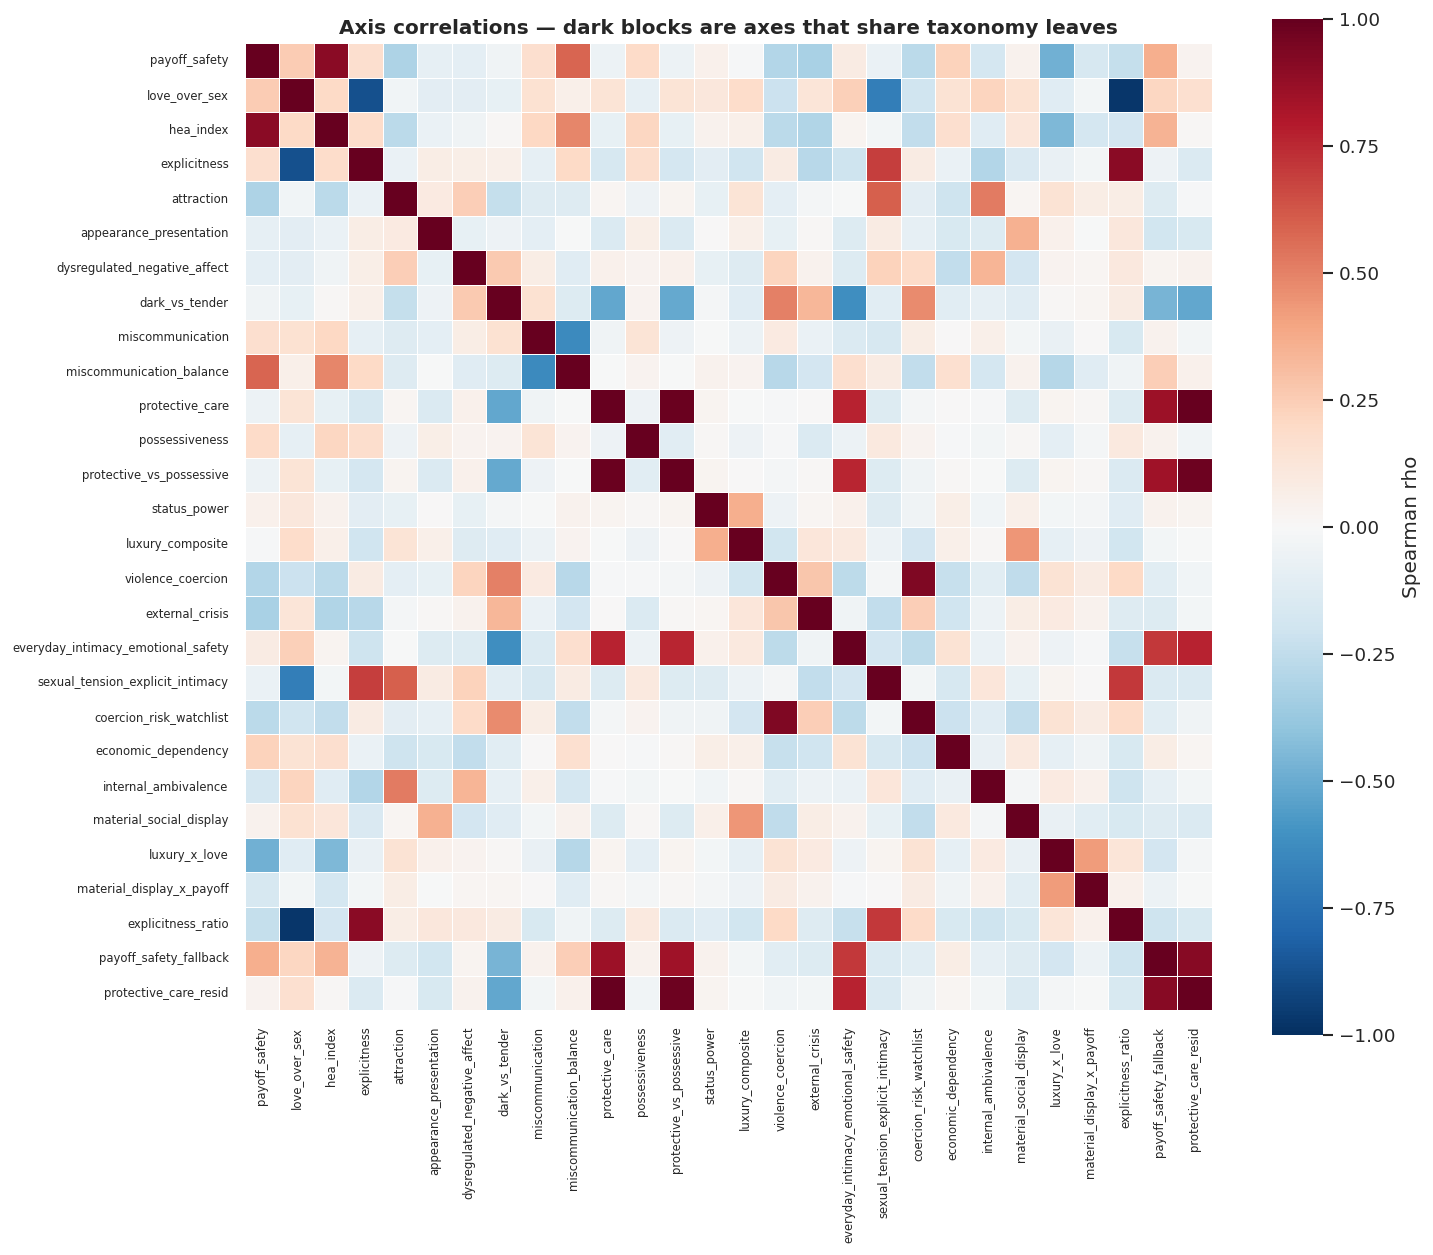

In [6]:
axis_corr = rel.axis_correlation_matrix(frame[AXIS_COLS], method="spearman")
redundant = rel.redundancy_flags(axis_corr, threshold=0.85)

print(f"Axis pairs correlated at |rho| >= 0.85: {len(redundant)}")
if len(redundant):
    display(redundant.round(3))
ctx.save_table(redundant, "redundant_axis_pairs")
ctx.save_table(axis_corr.reset_index().rename(columns={"index": "axis"}), "axis_correlations")

fig, ax = plt.subplots(figsize=(13, 11))
short = [c.removeprefix("AX_") for c in axis_corr.columns]
sns.heatmap(axis_corr.to_numpy(), cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=short, yticklabels=short, ax=ax,
            cbar_kws={"label": "Spearman rho"}, square=True, linewidths=0.3)
ax.tick_params(labelsize=7)
ax.set_title("Axis correlations — dark blocks are axes that share taxonomy leaves")
ctx.save_figure(fig, "axis_correlation_matrix")
plt.show()

## 6. Can the confirmatory axes go into one model together?

Variance inflation factors, computed on the CLR-transformed axes that notebook 05 actually
regresses. A VIF above 10 means the coefficient is not separately identified from the others.
Where that happens, the hypothesis is tested one axis at a time instead of jointly.

In [7]:
confirmatory_axes = [
    a for a in axis_summary.loc[axis_summary["hypothesis_role"] == "confirmatory", "axis"]
    if a in frame.columns
]
clr_names = [f"{a}_clr" for a in confirmatory_axes if f"{a}_clr" in frame.columns]

vif = mdl.variance_inflation(frame, clr_names)
vif["predictor"] = vif["predictor"].str.removesuffix("_clr")
vif["separately_identified"] = vif["vif"] < 10
display(vif.round(3))
ctx.save_table(vif, "axis_vif")

print(f"\nAxes with VIF >= 10: {int((~vif['separately_identified']).sum())}")
print("Where an axis is not separately identified, notebook 05 tests it in its own model")
print("rather than jointly, and says so in the results table.")

,predictor,vif,r_squared,separately_identified
0,AX_payoff_safety,5.7310,0.8260,True
1,AX_hea_index,5.5210,0.8190,True
2,AX_love_over_sex,3.6560,0.7260,True
3,AX_explicitness,3.6230,0.7240,True
4,AX_luxury_composite,1.9240,0.4800,True
5,AX_protective_care,1.6150,0.3810,True
6,AX_status_power,1.6130,0.3800,True
7,AX_protective_vs_possessive,1.3900,0.2800,True
8,AX_dark_vs_tender,1.3430,0.2560,True
9,AX_material_social_display,1.2740,0.2150,True


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/tables/axis_vif.csv  (12 rows)

Axes with VIF >= 10: 0
Where an axis is not separately identified, notebook 05 tests it in its own model
rather than jointly, and says so in the results table.


## 7. The distributions the hypotheses will be tested on

Contrast axes are centred near zero by construction, and both tails matter: a book at the
negative end of `AX_love_over_sex` is explicitly sexual relative to its emotional content,
not merely low on something. Worth looking at before the tests, so no result later comes as
a distributional surprise.

**This is a measurement check, not a results plot.** Each panel asks whether the theoretical
measure actually varies across books. For contrast axes, zero represents balance between the
two sides. Positive values mean the book contains relatively more of one side; negative
values mean relatively more of the other. A variable that collapses to a spike at zero
cannot test any hypothesis regardless of how clever the model is.

  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/figures/confirmatory_axis_distributions.png


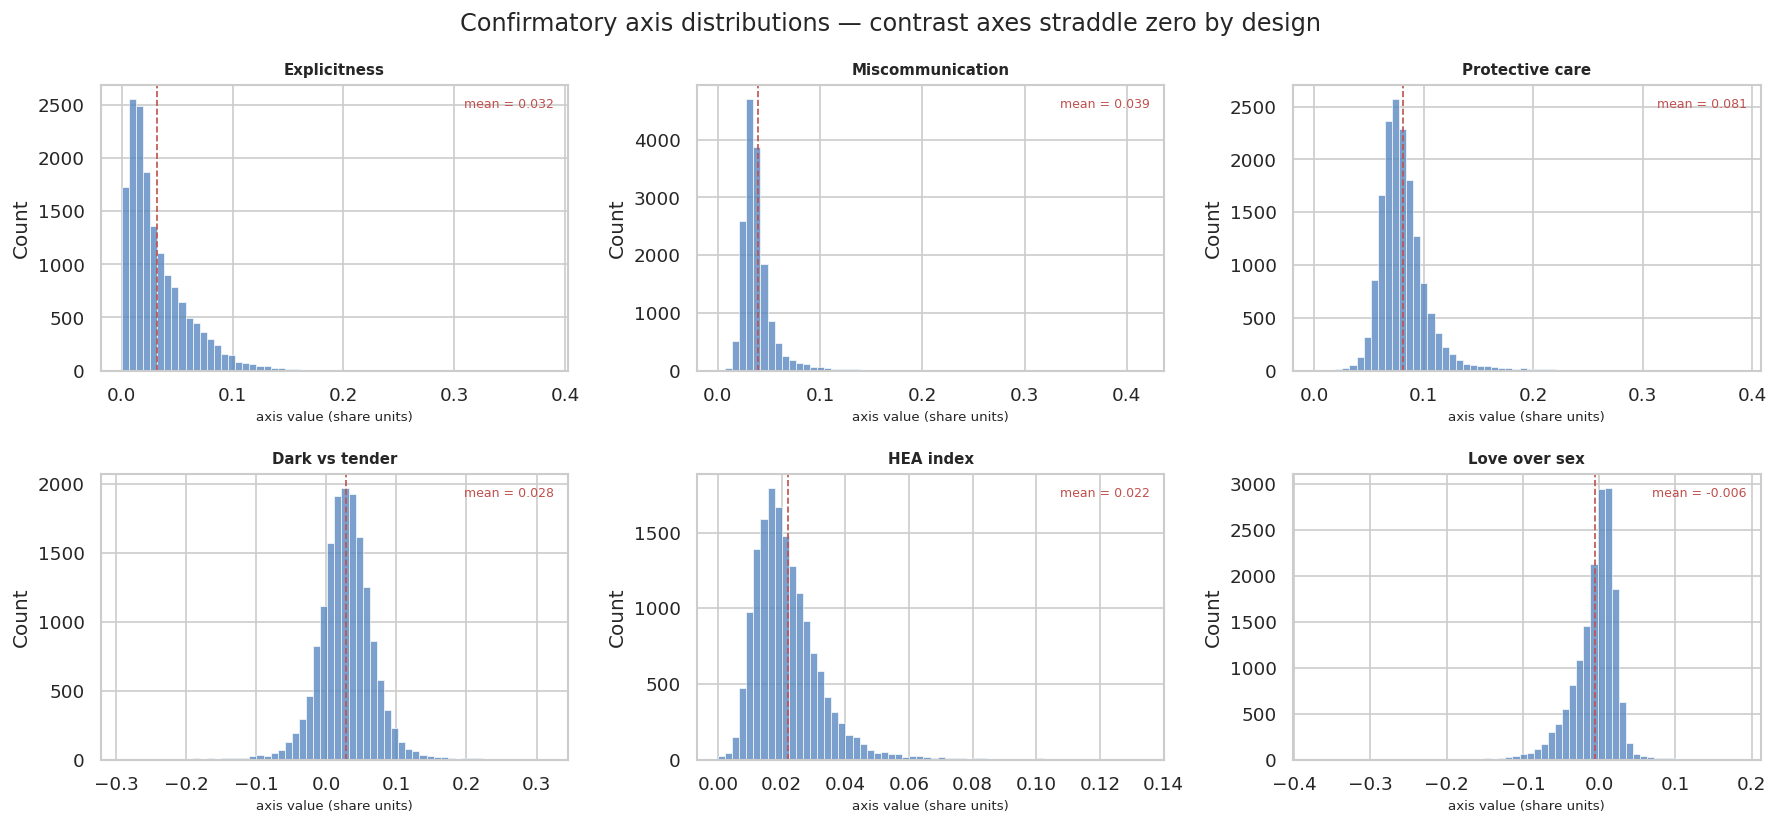

,n,mean,sd,min,median,max
AX_explicitness,"16,000.0000",0.0322,0.0288,0.0000,0.0231,0.3836
AX_miscommunication,"16,000.0000",0.0388,0.0195,0.0000,0.0348,0.4160
AX_protective_care,"16,000.0000",0.0813,0.0242,0.0000,0.0776,0.3881
AX_dark_vs_tender,"16,000.0000",0.0280,0.0404,-0.2916,0.0282,0.3148
AX_hea_index,"16,000.0000",0.0220,0.0111,0.0000,0.0199,0.1336
AX_love_over_sex,"16,000.0000",-0.0059,0.0298,-0.3740,0.0003,0.1837
AX_luxury_composite,"16,000.0000",0.0043,0.0086,0.0000,0.0029,0.2517
AX_material_social_display,"16,000.0000",0.0468,0.0154,0.0000,0.0445,0.2785
AX_payoff_safety,"16,000.0000",0.0263,0.0116,0.0000,0.0246,0.1837
AX_possessiveness,"16,000.0000",0.0014,0.0067,0.0000,0.0006,0.2050


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/tables/axis_distributions.csv  (12 rows)


In [8]:
_AXIS_HUMAN = {
    "explicitness": "Explicitness",
    "miscommunication": "Miscommunication",
    "protective_care": "Protective care",
    "dark_vs_tender": "Dark vs tender",
    "hea_index": "HEA index",
    "love_over_sex": "Love over sex",
}
panel = confirmatory_axes[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), panel):
    sns.histplot(frame[col], bins=60, ax=ax, color="#4f81bd")
    m = float(frame[col].mean())
    ax.axvline(m, color="#c0504d", ls="--", lw=1)
    ax.text(0.97, 0.92, f"mean = {m:.3f}", transform=ax.transAxes, ha="right",
            fontsize=7.5, color="#c0504d")
    raw = col.removeprefix("AX_")
    ax.set_title(_AXIS_HUMAN.get(raw, raw.replace("_", " ").capitalize()), fontsize=9)
    ax.set_xlabel("axis value (share units)", fontsize=8)
for ax in axes.ravel()[len(panel):]:
    ax.axis("off")
fig.suptitle("Confirmatory axis distributions — contrast axes straddle zero by design")
fig.tight_layout(pad=1.1, w_pad=1.4, h_pad=1.4)
ctx.save_figure(fig, "confirmatory_axis_distributions")
plt.show()

axis_stats = frame[confirmatory_axes].describe().T[["count", "mean", "std", "min", "50%", "max"]]
axis_stats.columns = ["n", "mean", "sd", "min", "median", "max"]
display(axis_stats.round(4))
ctx.save_table(axis_stats.reset_index().rename(columns={"index": "axis"}), "axis_distributions")

## 8. Log-ratio forms for the balance hypotheses

H1 and H4 are stated as balances — "love **over** sex", "protective **versus** possessive" —
and for compositional data the natural expression of a balance is a log-ratio, not a
difference:

\[ \text{LR} = \log\frac{\sum \text{numerator leaves} + \varepsilon}{\sum \text{denominator leaves} + \varepsilon} \]

The log-ratio is scale-free, exactly antisymmetric (swapping the legs flips the sign), and
unaffected by the rest of the composition. The difference form is kept alongside it because
it is easier to read in percentage points; both are reported in notebook 05, and agreement
between them is itself a robustness check.

If both approaches rank books similarly, the operationalisation is reasonably robust. If they
disagree, conclusions depend on how the balance was mathematically encoded. The result below
shows that **love-over-sex** is robust (Spearman ρ ≈ 0.895), while **protection-vs-possessiveness**
is very measurement-sensitive (ρ ≈ 0.338): two reasonable encodings give substantially
different book orderings.

LR_H1_love_over_sex: mean +1.880, sd 1.023, range [-1.77, +9.52]
LR_H4_protective_versus_possessive: mean +4.931, sd 1.183, range [-1.47, +8.45]


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/figures/log_ratio_vs_difference.png


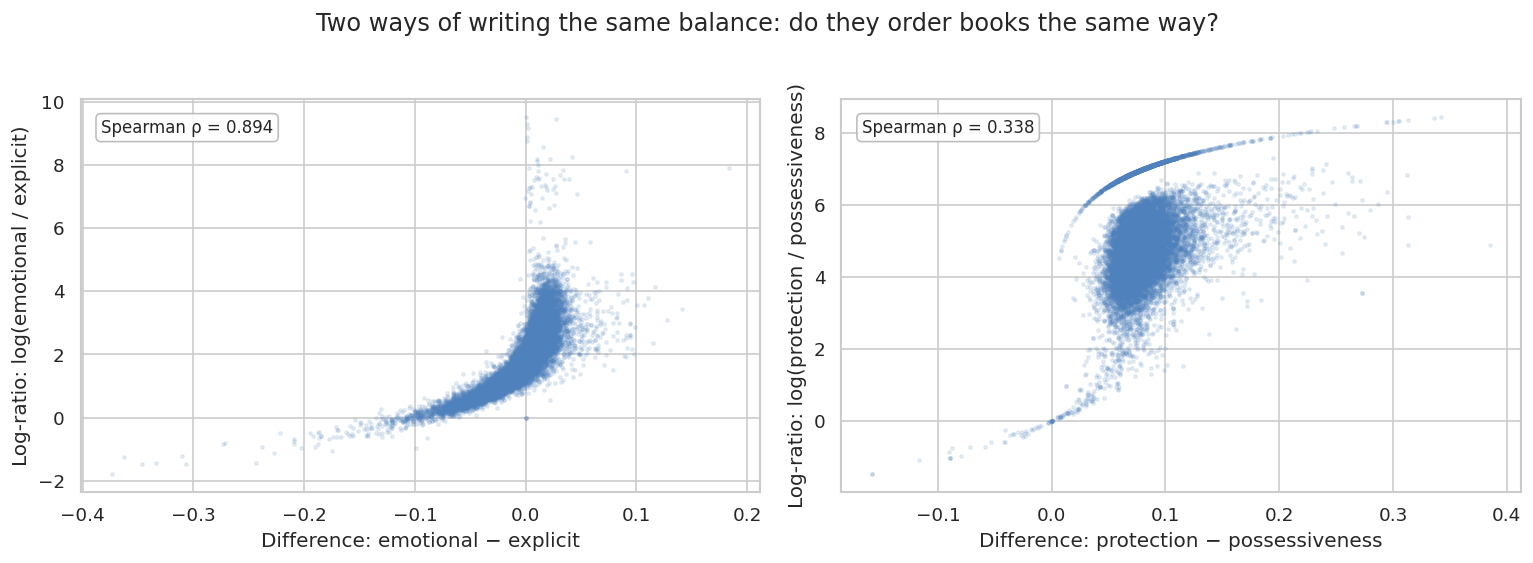

,log_ratio,difference_axis,spearman_rho
0,LR_H1_love_over_sex,AX_love_over_sex,0.8945
1,LR_H4_protective_versus_possessive,AX_protective_vs_possessive,0.3377


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/tables/log_ratio_agreement.csv  (2 rows)


In [9]:
for col in LOG_RATIO_COLS:
    print(f"{col}: mean {frame[col].mean():+.3f}, sd {frame[col].std():.3f}, "
          f"range [{frame[col].min():+.2f}, {frame[col].max():+.2f}]")

pairs = [("LR_H1_love_over_sex", "AX_love_over_sex"),
         ("LR_H4_protective_versus_possessive", "AX_protective_vs_possessive")]
pairs = [(lr, ax) for lr, ax in pairs if lr in frame.columns and ax in frame.columns]

_PAIR_LABELS = {
    "LR_H1_love_over_sex": ("Difference: emotional − explicit",
                             "Log-ratio: log(emotional / explicit)"),
    "LR_H4_protective_versus_possessive": ("Difference: protection − possessiveness",
                                            "Log-ratio: log(protection / possessiveness)"),
}

fig, axes = plt.subplots(1, len(pairs), figsize=(6.5 * len(pairs), 4.6))
axes = np.atleast_1d(axes)
agreement_rows = []
for ax, (lr_col, ax_col) in zip(axes, pairs):
    rho = float(frame[lr_col].corr(frame[ax_col], method="spearman"))
    ax.scatter(frame[ax_col], frame[lr_col], s=4, alpha=0.12, color="#4f81bd")
    xlbl, ylbl = _PAIR_LABELS.get(lr_col, (ax_col, lr_col))
    ax.set_xlabel(xlbl)
    ax.set_ylabel(ylbl)
    ax.text(0.03, 0.95, f"Spearman ρ = {rho:.3f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.85))
    agreement_rows.append({"log_ratio": lr_col, "difference_axis": ax_col, "spearman_rho": rho})
fig.suptitle("Two ways of writing the same balance: do they order books the same way?", y=1.02)
fig.tight_layout(pad=1.2)
ctx.save_figure(fig, "log_ratio_vs_difference")
plt.show()

display(pd.DataFrame(agreement_rows).round(4))
ctx.save_table(pd.DataFrame(agreement_rows), "log_ratio_agreement")

## 9. Strict versus generous mapping

Each topic gets a primary taxonomy category, and 239 of the 348 topics also get a secondary.
The **strict** axes use primary assignments only; the **generous** axes add secondary
assignments at half weight.

If a conclusion depends on which variant is used, it depends on Stage 09's judgement calls
about ambiguous topics rather than on the corpus. High agreement here is what licenses using
strict as primary throughout; notebook 08 re-runs the hypothesis tests under generous.

Axes compared: 26
  median Spearman rho between variants: 0.916
  axes below rho 0.90:                  12


,axis,spearman_rho,pearson_r,mean_strict,mean_generous,robust_to_mapping
13,AX_status_power,0.3347,0.9704,0.0013,0.0029,False
14,AX_luxury_composite,0.6286,0.8969,0.0043,0.0101,False
23,AX_luxury_x_love,0.6394,0.7414,0.0000,0.0000,False
11,AX_possessiveness,0.6908,0.9902,0.0014,0.0017,False
8,AX_miscommunication,0.7976,0.9276,0.0388,0.0415,False
7,AX_dark_vs_tender,0.8076,0.8565,0.0280,0.0469,False
17,AX_everyday_intimacy_emotional_safety,0.8120,0.8944,0.1261,0.1240,False
24,AX_material_display_x_payoff,0.8157,0.6877,0.0000,-0.0000,False
6,AX_dysregulated_negative_affect,0.8415,0.8290,0.0325,0.0521,False
22,AX_material_social_display,0.8811,0.8359,0.0468,0.0588,False


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/tables/strict_vs_generous_mapping.csv  (26 rows)


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/figures/strict_vs_generous_mapping.png


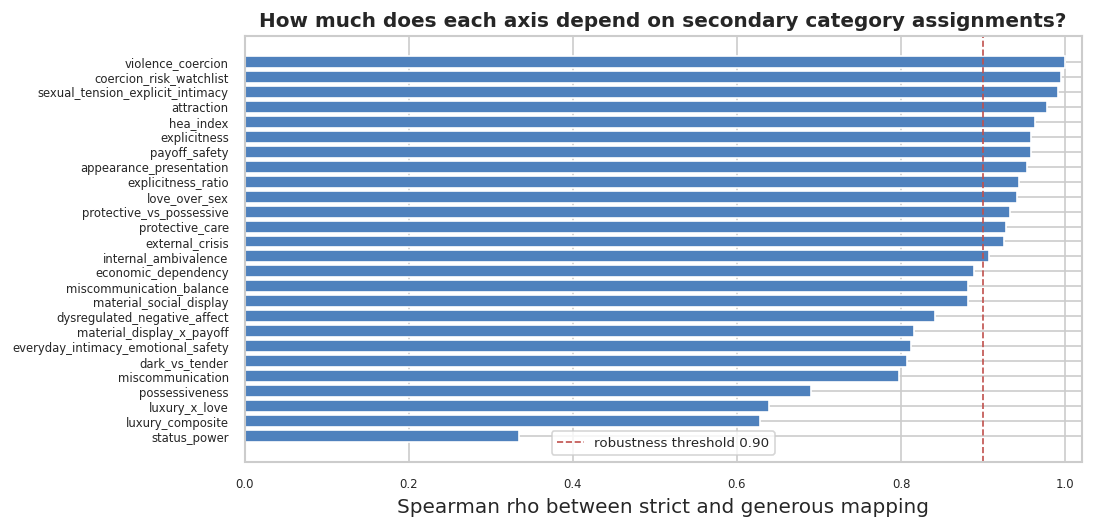

In [10]:
strict = nbh.load_book_features(cfg, "book_axes_strict").set_index("book_id")
generous = nbh.load_book_features(cfg, "book_axes_generous").set_index("book_id")
shared = [c for c in strict.columns if c in generous.columns]

mapping_rows = []
for col in shared:
    left, right = strict[col], generous[col].reindex(strict.index)
    valid = pd.concat([left, right], axis=1).dropna()
    if len(valid) < 100 or valid.iloc[:, 0].std() == 0 or valid.iloc[:, 1].std() == 0:
        continue
    mapping_rows.append({
        "axis": col,
        "spearman_rho": float(valid.iloc[:, 0].corr(valid.iloc[:, 1], method="spearman")),
        "pearson_r": float(valid.iloc[:, 0].corr(valid.iloc[:, 1])),
        "mean_strict": float(valid.iloc[:, 0].mean()),
        "mean_generous": float(valid.iloc[:, 1].mean()),
    })

mapping = pd.DataFrame(mapping_rows).sort_values("spearman_rho")
mapping["robust_to_mapping"] = mapping["spearman_rho"] >= 0.90

print(f"Axes compared: {len(mapping)}")
print(f"  median Spearman rho between variants: {mapping['spearman_rho'].median():.3f}")
print(f"  axes below rho 0.90:                  {int((~mapping['robust_to_mapping']).sum())}")
display(mapping.round(4))
ctx.save_table(mapping, "strict_vs_generous_mapping")

fig, ax = plt.subplots(figsize=(9, 4.6))
ordered = mapping.sort_values("spearman_rho")
ax.barh(ordered["axis"].str.removeprefix("AX_"), ordered["spearman_rho"], color="#4f81bd")
ax.axvline(0.90, color="#c0504d", ls="--", lw=1, label="robustness threshold 0.90")
ax.set_xlim(0, 1.02)
ax.set_xlabel("Spearman rho between strict and generous mapping")
ax.tick_params(labelsize=7)
ax.set_title("How much does each axis depend on secondary category assignments?")
ax.legend(fontsize=8)
ctx.save_figure(fig, "strict_vs_generous_mapping")
plt.show()

## 10. Testability verdicts

The gate before notebook 05. Each hypothesis gets one of four statuses, and the reasoning is
recorded so a reader can disagree with the judgement rather than having to reverse-engineer
it.

In [11]:
def axis_row(axis_name):
    match = validity[validity["axis"] == axis_name]
    return match.iloc[0] if len(match) else None


hypotheses = cfg.get("hypotheses", {})
verdict_rows = []
for key in sorted(hypotheses):
    spec_cfg = hypotheses[key]
    axis_name = spec_cfg.get("primary_axis")
    coverage_row = axis_summary[axis_summary["axis"] == axis_name]
    validity_row = axis_row(axis_name)

    n_empty = int(coverage_row.iloc[0]["n_empty"]) if len(coverage_row) else np.nan
    n_viable = int(coverage_row.iloc[0]["n_viable"]) if len(coverage_row) else np.nan
    coverage_verdict = coverage_row.iloc[0]["axis_verdict"] if len(coverage_row) else "missing"

    if spec_cfg.get("level") == "tertile":
        rising = [l for l in spec_cfg.get("rising_leaves", []) if f"leaf_{l}" in frame.columns]
        falling = [l for l in spec_cfg.get("falling_leaves", []) if f"leaf_{l}" in frame.columns]
        status = "testable" if rising and falling else "not measurable"
        reason = (f"within-book design at tertile level; {len(rising)} rising and "
                  f"{len(falling)} falling leaves available")
        coverage_verdict = "tertile-level"
    elif axis_name not in frame.columns:
        status, reason = "not measurable", "axis could not be built from existing topics"
    elif key == "H3":
        status = "reframed"
        reason = ("original luxury formulation has no topics (6.1a, 6.6, 6.7 empty); "
                  "tested as material/social display instead")
    elif coverage_verdict == "weak" and n_viable <= 1:
        status, reason = "underpowered", f"{n_empty} empty and only {n_viable} viable component(s)"
    elif coverage_verdict == "weak":
        status, reason = "testable with caveats", f"{n_viable} viable but {n_empty} empty component(s)"
    else:
        status, reason = "testable", "all components viable"

    verdict_rows.append({
        "hypothesis": key,
        "name": spec_cfg.get("name"),
        "primary_axis": axis_name,
        "coverage_verdict": coverage_verdict,
        "validity_verdict": validity_row["verdict"] if validity_row is not None else "-",
        "n_viable_components": n_viable,
        "n_empty_components": n_empty,
        "status": status,
        "reason": reason,
        "power_note": spec_cfg.get("power_note", ""),
    })

verdicts = pd.DataFrame(verdict_rows)
display(verdicts)
ctx.save_table(verdicts, "hypothesis_testability")

print("\nStatus summary:")
display(verdicts["status"].value_counts().to_frame("n_hypotheses"))

,hypothesis,name,primary_axis,coverage_verdict,validity_verdict,n_viable_components,n_empty_components,status,reason,power_note
0,H1,Love over sex,AX_love_over_sex,weak,questionable,2.0000,0.0000,testable with caveats,2 viable but 0 empty component(s),"Well populated — 30 topics on 4.6, 18 on 2.1, ..."
1,H2,Happily-ever-after,AX_hea_index,weak,questionable,1.0000,0.0000,underpowered,0 empty and only 1 viable component(s),5.3a and 8.3a rest on one topic each; 4.5 alon...
2,H3,Material and social display,AX_material_social_display,weak,questionable,2.0000,0.0000,reframed,original luxury formulation has no topics (6.1...,
3,H4,Protective versus possessive,AX_protective_vs_possessive,weak,questionable,1.0000,0.0000,underpowered,0 empty and only 1 viable component(s),4.7 has 2 topics; the negative leg is underpow...
4,H5,Dark versus tender,AX_dark_vs_tender,weak,questionable,6.0000,0.0000,testable with caveats,6 viable but 0 empty component(s),
5,H6,Narrative arc,None,tertile-level,-,NaN,NaN,testable,within-book design at tertile level; 3 rising ...,


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/tables/hypothesis_testability.csv  (6 rows)

Status summary:


,n_hypotheses
status,
testable with caveats,2
underpowered,2
reframed,1
testable,1


In [12]:
summary = pd.DataFrame([
    ("axes built", f"{len(AXIS_COLS)}"),
    ("viable coverage", f"{int((axis_summary['axis_verdict'] == 'viable').sum())}"),
    ("weak coverage", f"{int((axis_summary['axis_verdict'] == 'weak').sum())}"),
    ("validity: valid", f"{int((validity['verdict'] == 'valid').sum())}"),
    ("validity: usable, low reliability", f"{int((validity['verdict'] == 'usable_low_reliability').sum())}"),
    ("validity: questionable", f"{int((validity['verdict'] == 'questionable').sum())}"),
    ("validity: atomic (single component)", f"{int((validity['verdict'] == 'atomic').sum())}"),
    ("redundant axis pairs (|rho| >= 0.85)", f"{len(redundant)}"),
    ("axes not separately identified (VIF >= 10)", f"{int((~vif['separately_identified']).sum())}"),
    ("strict vs generous median rho", f"{mapping['spearman_rho'].median():.3f}"),
    ("hypotheses testable", f"{int((verdicts['status'] == 'testable').sum())} of {len(verdicts)}"),
], columns=["item", "value"])
display(summary)
ctx.save_table(summary, "chapter_summary")

print(
    "\nWhat carries into notebook 05:\n"
    "  Confirmatory axes are tested in the form defined in the pre-registered schema, not in\n"
    "  whichever form performs best.\n"
    "  Because no composite passed the reliability checks, each is reported alongside its\n"
    "  strongest single component, and the components are believed where they disagree.\n"
    "  Axes marked atomic or weak carry their power limits into the results table, so a null\n"
    "  result on a one-topic leg is not read as evidence against the theory.\n"
    "  Balance hypotheses are reported in both difference and log-ratio form.\n"
    f"  AX_payoff_safety and AX_hea_index have VIF above 10 (they are both essentially leaf\n"
    f"  4.5), so they are never entered in the same model.\n"
)
print("Next: 05_hypothesis_tests.ipynb — H1 to H6 with effect sizes, models and arc analysis.")

,item,value
0,axes built,28
1,viable coverage,10
2,weak coverage,13
3,validity: valid,0
4,"validity: usable, low reliability",1
5,validity: questionable,11
6,validity: atomic (single component),11
7,redundant axis pairs (|rho| >= 0.85),10
8,axes not separately identified (VIF >= 10),0
9,strict vs generous median rho,0.916


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/04_composites_validity/tables/chapter_summary.csv  (11 rows)

What carries into notebook 05:
  Confirmatory axes are tested in the form defined in the pre-registered schema, not in
  whichever form performs best.
  Because no composite passed the reliability checks, each is reported alongside its
  strongest single component, and the components are believed where they disagree.
  Axes marked atomic or weak carry their power limits into the results table, so a null
  result on a one-topic leg is not read as evidence against the theory.
  Balance hypotheses are reported in both difference and log-ratio form.
  AX_payoff_safety and AX_hea_index have VIF above 10 (they are both essentially leaf
  4.5), so they are never entered in the same model.

Next: 05_hypothesis_tests.ipynb — H1 to H6 with effect sizes, models and arc analysis.
